# Titanic


## Import Library


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Datasets


In [2]:
train_data = pd.read_csv("data/train.csv")
test_data = pd.read_csv("data/test.csv")

# データの連結
test_data["Survived"] = np.nan
all_df = pd.concat([train_data, test_data], ignore_index=True, sort=False)

# データの情報
print(all_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB
None


## Observe Data


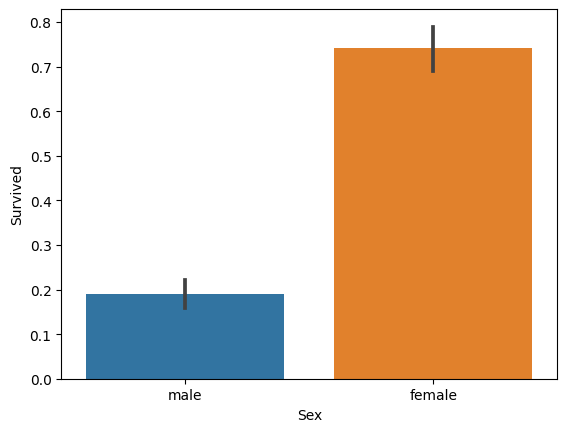

In [3]:
# 性別ごとの生存者数
sns.barplot(x="Sex", y="Survived", data=all_df)
plt.show()

## Handling Missing Values


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


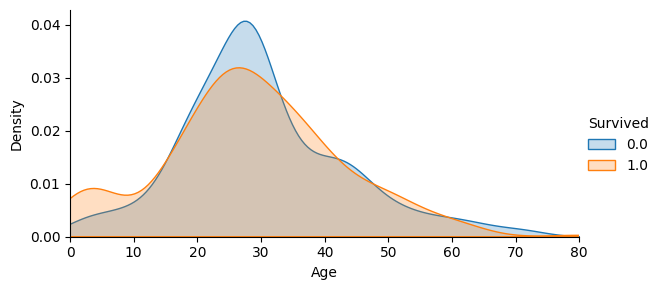

In [4]:
from sklearn.ensemble import RandomForestRegressor

# AgeをPclass, Sex, Parch,SibSpで予測する
predict_age_df = all_df[["Age", "Pclass", "Sex", "Parch", "SibSp"]]
# ワンホットエンコーディング
predict_age_df = pd.get_dummies(predict_age_df)

# 学習データとテストデータに分離して、numpyに変換
known_age = predict_age_df[predict_age_df.Age.notnull()].values
unknown_age = predict_age_df[predict_age_df.Age.isnull()].values

# 学習データを訓練データとテストデータに分離
x = known_age[:, 1:]
y = known_age[:, 0]

# ランダムフォレスト回帰モデルの作成
rf_reg = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)
rf_reg.fit(x, y)

predicted_age = rf_reg.predict(unknown_age[:, 1::])
all_df.loc[all_df["Age"].isnull(), "Age"] = predicted_age

# 年齢別の生存曲線と死亡曲線
facet = sns.FacetGrid(all_df[0:890], hue="Survived", aspect=2)
facet.map(sns.kdeplot, "Age", fill=True)
facet.set(xlim=(0, all_df.loc[0:890, "Age"].max()))
facet.add_legend()
plt.show()

## Create New Feature by Name


/tmp/ipykernel_24222/3862322297.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_df["Title"].replace(["Capt", "Col", "Major", "Dr", "Rev"], "Officer", inplace=True)
/usr/local/lib/python3.11/dist-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))


<Axes: xlabel='Title', ylabel='Survived'>

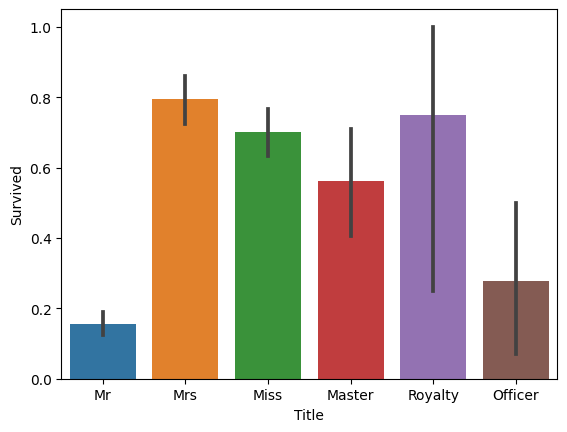

In [5]:
# Nameから敬称を抽出
all_df["Title"] = all_df["Name"].map(lambda x: x.split(",")[1].split(".")[0].strip())
# 軍や医療、宗教関係の敬称を「Officer」に統一
all_df["Title"].replace(["Capt", "Col", "Major", "Dr", "Rev"], "Officer", inplace=True)
# 貴族や上流階級の敬称を「Royalty」に統一
all_df["Title"].replace(["Don", "Sir", "the Countess", "Lady", "Dona"], "Royalty", inplace=True)
# 既婚女性の異なる表記を「Mrs」に統一
all_df["Title"].replace(["Mme", "Ms"], "Mrs", inplace=True)
# 未婚女性の異なる表記を「Miss」に統一
all_df["Title"].replace(["Mlle"], "Miss", inplace=True)
# オランダの若い男性の敬称を「Master」に統一
all_df["Title"].replace(["Jonkheer"], "Master", inplace=True)

sns.barplot(x="Title", y="Survived", data=all_df)

In [6]:
# Nameから苗字を抽出
all_df["Surname"] = all_df["Name"].map(lambda x: x.split(",")[0].strip())

# 同じ苗字の人数をカウント
all_df["FamilySize"] = all_df["Surname"].map(all_df["Surname"].value_counts())

In [7]:
# 家族で、女性か子供のグループ
female_and_child = all_df.loc[(all_df["FamilySize"] >= 2) & ((all_df["Sex"] == "female") | (all_df["Age"] <= 16))]
# 苗字(家族)ごとの生存率
female_and_child = female_and_child.groupby("Surname")["Survived"].mean()
(female_and_child.value_counts())

Survived
1.000000    113
0.000000     32
0.750000      2
0.500000      1
0.333333      1
0.142857      1
Name: count, dtype: int64

In [8]:
# 家族で、男性かつ大人のグループ
male_and_adult = all_df.loc[(all_df["FamilySize"] >= 2) & ((all_df["Sex"] == "male") & (all_df["Age"] > 16))]
# 苗字(家族)ごとの生存率
male_and_adult = male_and_adult.groupby("Surname")["Survived"].mean()
(male_and_adult.value_counts())

Survived
0.000000    115
1.000000     21
0.500000      6
0.333333      2
0.250000      1
Name: count, dtype: int64

In [9]:
# 死亡者リスト
dead_list = set(female_and_child[female_and_child.apply(lambda x: x == 0)].index)
# 生存者リスト
survived_list = set(male_and_adult[male_and_adult.apply(lambda x: x == 1)].index)
# それぞれのリストを表示
print(dead_list)
print(survived_list)
# 死亡者リストと生存者リストをもとに、Sex, Age, Titleを典型的なものに統一
all_df.loc[
    (all_df["Survived"].isnull()) & (all_df["Surname"].apply(lambda x: x in dead_list)), ["Sex", "Age", "Title"]
] = ["male", 30.0, "Mr"]
all_df.loc[
    (all_df["Survived"].isnull()) & (all_df["Surname"].apply(lambda x: x in survived_list)), ["Sex", "Age", "Title"]
] = ["female", 5.0, "Mrs"]

{'Arnold-Franchi', 'Cacic', 'Rosblom', 'Attalah', 'Barbara', 'Robins', 'Bourke', 'Van Impe', 'Sage', 'Ford', 'Lahtinen', 'Danbom', 'Vander Planke', 'Johnston', 'Goodwin', 'Caram', 'Panula', 'Turpin', 'Ilmakangas', 'Elias', 'Canavan', 'Rice', 'Jussila', 'Zabour', 'Strom', 'Olsson', 'Palsson', 'Lobb', 'Boulos', 'Oreskovic', 'Lefebre', 'Skoog'}
{'Goldenberg', 'Frolicher-Stehli', 'Jonsson', 'Cardeza', 'Dick', 'Chambers', 'Greenfield', 'Moubarek', 'Bradley', 'Beckwith', 'Duff Gordon', 'Nakid', 'Beane', 'Taylor', 'Daly', 'Kimball', 'Jussila', 'Bishop', 'McCoy', 'Harder', 'Frauenthal'}


## Handling Missing Fare Values


In [10]:
# Fareの欠損値をEmbarked='S', Pclass=3 の平均値で埋める
fare = all_df.loc[(all_df["Embarked"] == "S") & (all_df["Pclass"] == 3), "Fare"].mean()
all_df["Fare"] = all_df["Fare"].fillna(fare)

## Create New Feature by SibSp, Parch


In [11]:
all_df["Family"] = all_df["SibSp"] + all_df["Parch"] + 1
# ラベリング
all_df.loc[(all_df["Family"] > 1) & (all_df["Family"] < 5), "Family_Label"] = 2
all_df.loc[(all_df["Family"] >= 5) & (all_df["Family"] < 8) | (all_df["Family"] == 1), "Family_Label"] = 1
all_df.loc[all_df["Family"] >= 8, "Family_Label"] = 0

In [12]:
## Create New Feature by Ticket

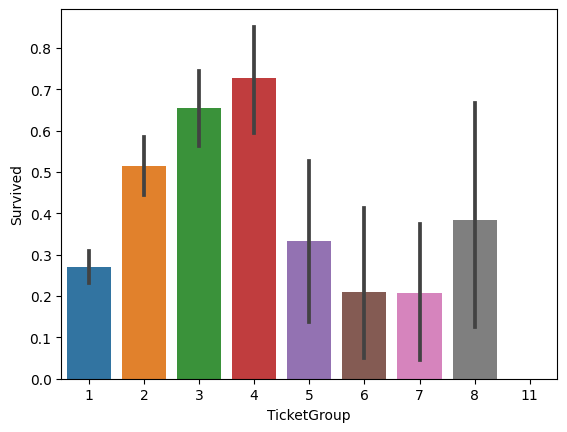

In [13]:
ticket_count = dict(all_df["Ticket"].value_counts())
all_df["TicketGroup"] = all_df["Ticket"].map(ticket_count)

sns.barplot(x="TicketGroup", y="Survived", data=all_df)
plt.show()

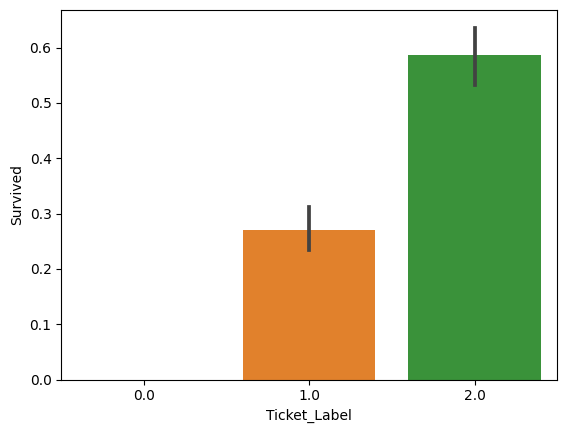

In [14]:
# 生存率で3つにグルーピング
all_df.loc[(all_df["TicketGroup"] >= 2) & (all_df["TicketGroup"] <= 4), "Ticket_Label"] = 2
all_df.loc[
    (all_df["TicketGroup"] >= 5) & (all_df["TicketGroup"] <= 8) | (all_df["TicketGroup"] == 1), "Ticket_Label"
] = 1
all_df.loc[(all_df["TicketGroup"] >= 11), "Ticket_Label"] = 0
sns.barplot(x="Ticket_Label", y="Survived", data=all_df)
plt.show()

## Labeling Cabin


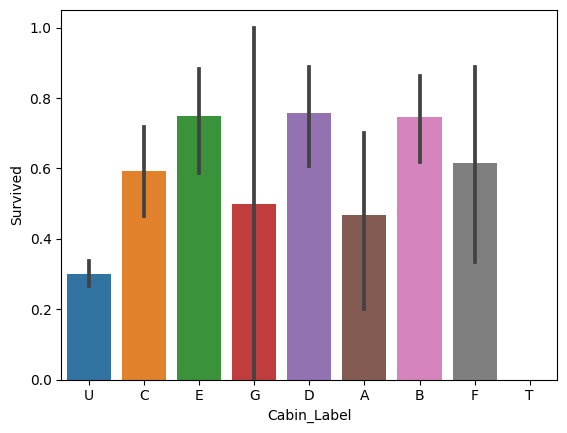

In [15]:
# Cabinの欠損値をUnknownで埋める
all_df["Cabin"] = all_df["Cabin"].fillna("Unknown")
# Cabinの先頭の文字をラベルにする
all_df["Cabin_Label"] = all_df["Cabin"].str.get(0)

sns.barplot(x="Cabin_Label", y="Survived", data=all_df)
plt.show()

## Handling Missing Embarked Values


In [16]:
all_df["Embarked"] = all_df["Embarked"].fillna("S")

## Preprocessing for Model


In [17]:
all_df = all_df[
    ["Survived", "Pclass", "Sex", "Age", "Fare", "Embarked", "Title", "Family_Label", "Cabin_Label", "Ticket_Label"]
]

# ワンホットエンコーディング
all_df = pd.get_dummies(all_df)

# 訓練データとテストデータに分離
train_df = all_df[all_df["Survived"].notnull()]
train_df["Survived"] = train_df["Survived"]
test_df = all_df[all_df["Survived"].isnull()].drop("Survived", axis=1)

# 訓練データとテストデータをnumpyに変換
x = train_df.values[:, 1:]
y = train_df.values[:, 0]
y = y.astype("int")

# 訓練データとテストデータをnumpyに変換
test_x = test_df.values

/tmp/ipykernel_24222/1131020238.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["Survived"] = train_df["Survived"]


## Model Training


In [18]:
from sklearn.feature_selection import SelectKBest
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate

select = SelectKBest(k=16)

clf = RandomForestClassifier(
    random_state=10,
    warm_start=True,
    n_estimators=26,
    max_depth=6,
    max_features="sqrt",
)
pipeline = make_pipeline(select, clf)
pipeline.fit(x, y)

# フィット結果の表示
cv_result = cross_validate(pipeline, x, y, cv=10)
print("mean_score = ", np.mean(cv_result["test_score"]))
print("mean_std = ", np.std(cv_result["test_score"]))

/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [23] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


mean_score =  0.8395006242197253
mean_std =  0.04412385603352972


In [19]:
mask = select.get_support()

list_col = list(all_df.columns[1:])

for i, j in enumerate(list_col):
    print(f"No.{i+1}: {j}={mask[i]}")

x_selected = select.transform(x)
print(f"x.shape={x.shape}, x_selected.shape={x_selected.shape}")

No.1: Pclass=True
No.2: Age=False
No.3: Fare=True
No.4: Family_Label=True
No.5: Ticket_Label=True
No.6: Sex_female=True
No.7: Sex_male=True
No.8: Embarked_C=True
No.9: Embarked_Q=False
No.10: Embarked_S=True
No.11: Title_Master=False
No.12: Title_Miss=True
No.13: Title_Mr=True
No.14: Title_Mrs=True
No.15: Title_Officer=False
No.16: Title_Royalty=False
No.17: Cabin_Label_A=False
No.18: Cabin_Label_B=True
No.19: Cabin_Label_C=True
No.20: Cabin_Label_D=True
No.21: Cabin_Label_E=True
No.22: Cabin_Label_F=False
No.23: Cabin_Label_G=False
No.24: Cabin_Label_T=False
No.25: Cabin_Label_U=True
x.shape=(891, 25), x_selected.shape=(891, 16)


In [20]:
passenger_id = test_data["PassengerId"]
predicted = pipeline.predict(test_x)

# 提出用データの作成
submission = pd.DataFrame({"PassengerId": passenger_id, "Survived": predicted.astype(np.int32)})
submission.to_csv("submission2.csv", index=False)